In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data Understanding


In [4]:
df = pd.read_csv('data.csv',parse_dates=[0])
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,2015-01-01,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,NaN,0.0,59.0,0.940725
1,2015-01-01,Quarter1,finishing,Thursday,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,2015-01-01,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,2015-01-01,Quarter1,sweing,Thursday,12.0,0.80,11.41,NaN,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
4,2015-01-01,Quarter1,sweing,Thursday,6.0,NaN,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.800382


In [5]:
df.shape

(1302, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1272 non-null   datetime64[ns]
 1   quarter                1279 non-null   object        
 2   department             1275 non-null   object        
 3   day                    1274 non-null   object        
 4   team                   1278 non-null   float64       
 5   targeted_productivity  1279 non-null   float64       
 6   smv                    1276 non-null   float64       
 7   wip                    729 non-null    float64       
 8   over_time              1276 non-null   float64       
 9   incentive              1275 non-null   float64       
 10  idle_time              1275 non-null   float64       
 11  idle_men               1278 non-null   float64       
 12  no_of_style_change     1279 non-null   float64       
 13  no_

In [7]:
df.describe()

,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1272,1278.000000,1279.000000,1276.000000,729.000000,1276.000000,1275.000000,1275.000000,1278.000000,1279.000000,1280.000000,1267.000000
mean,2015-02-04 09:06:47.547170048,6.443662,0.730274,15.061418,1148.422497,4551.332288,36.967843,0.688235,0.357590,0.146990,34.553906,0.734889
min,2015-01-01 00:00:00,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,2015-01-17 00:00:00,3.000000,0.700000,3.940000,762.000000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650173
50%,2015-02-04 00:00:00,7.000000,0.750000,15.260000,1040.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.763375
75%,2015-02-23 00:00:00,9.000000,0.800000,24.260000,1255.000000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850354
max,2015-03-11 00:00:00,12.000000,0.800000,54.560000,21540.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437
std,NaN,3.468331,0.096727,10.989957,1596.736245,3347.164546,155.419707,12.316019,3.191313,0.422717,22.256752,0.173802


In [8]:
df.isna().sum()

,0
date,30
quarter,23
department,27
day,28
team,24
targeted_productivity,23
smv,26
wip,573
over_time,26
incentive,27


In [9]:
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

if len(missing_cols) > 0:
      print(f"   Columns with missing values:")
      for col, count in missing_cols.items():
        pct = (count / len(df)) * 100
        print(f"      {col}: {count} ({pct:.1f}%)")
else:
      print(f"   No missing values found")

   Columns with missing values:
      date: 30 (2.3%)
      quarter: 23 (1.8%)
      department: 27 (2.1%)
      day: 28 (2.2%)
      team: 24 (1.8%)
      targeted_productivity: 23 (1.8%)
      smv: 26 (2.0%)
      wip: 573 (44.0%)
      over_time: 26 (2.0%)
      incentive: 27 (2.1%)
      idle_time: 27 (2.1%)
      idle_men: 24 (1.8%)
      no_of_style_change: 23 (1.8%)
      no_of_workers: 22 (1.7%)
      actual_productivity: 35 (2.7%)


In [10]:
print(f'Num of Duplicates : {int(df.duplicated().sum())}')

Num of Duplicates : 105


In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary[col] = len(outliers)

# Show how many outliers per column
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Number of Outliers'])
outlier_df.sort_values(by='Number of Outliers', ascending=False)

,Number of Outliers
no_of_style_change,154
targeted_productivity,82
actual_productivity,44
idle_time,19
idle_men,19
wip,17
incentive,11
over_time,1
team,0
smv,0


In [12]:
print("\n===== Skewness =====")
print(df.skew(numeric_only=True).sort_values(ascending=False))


===== Skewness =====
idle_time                21.205208
incentive                16.250960
wip                      10.576732
idle_men                 10.005870
no_of_style_change        2.980139
over_time                 0.669282
smv                       0.421104
team                      0.007135
no_of_workers            -0.106663
actual_productivity      -0.772093
targeted_productivity    -2.118908
dtype: float64


# Data Preprocessing

```
# Data Cleaning
```



In [13]:
# Remove missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
for col, count in missing_cols.items():
    pct = (count / len(df)) * 100
    # print(f"   {col}: {count} ({pct:.1f}%)")
    if pct < 5:
        df.dropna(subset=[col], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.drop_duplicates(keep='first',inplace=True)

In [16]:
# Remove outliers
cols = ['incentive','idle_time','idle_men','over_time']

# Calculate bounds for all columns first
bounds = {}
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    bounds[col] = {
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR
    }

# Apply filtering once
mask = pd.Series([True] * len(df))
for col in cols:
    mask = mask & (df[col] >= bounds[col]['lower']) & (df[col] <= bounds[col]['upper'])

df_clean = df[mask]
print(f"Original: {len(df)} rows, After outlier removal: {len(df_clean)} rows")

Original: 897 rows, After outlier removal: 665 rows


In [17]:
# Fix department name
df['department'] = df['department'].str.strip().str.lower()
df['department'] = df['department'].replace('sweing', 'sewing')

```
# Data Transformation
```

In [18]:
df_encoded = pd.get_dummies(df, columns=['department', 'day', 'quarter'], drop_first=True)

In [19]:
from sklearn.preprocessing import RobustScaler

num_cols = df.select_dtypes(include=[np.number]).columns
scaler = RobustScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [20]:
# Extract date features
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

```
# Feature Engineering
```

In [21]:
# Difference between target and actual
df_encoded['efficiency_gap'] = df_encoded['targeted_productivity'] - df_encoded['actual_productivity']

# Ratio of actual to target productivity
df_encoded['productivity_ratio'] = df_encoded['actual_productivity'] / (df_encoded['targeted_productivity'] + 1e-6)

# Workload per worker
df_encoded['wip_per_worker'] = df_encoded['wip'] / (df_encoded['no_of_workers'] + 1)

# Overtime per worker
df['overtime_per_worker'] = df['over_time'] / (df['no_of_workers'] + 1)

# Incentive per worker
df_encoded['incentive_per_worker'] = df_encoded['incentive'] / (df_encoded['no_of_workers'] + 1)

# Idle ratio (time lost due to interruptions)
df_encoded['idle_ratio'] = df_encoded['idle_time'] / (df_encoded['over_time'] + df_encoded['smv'] + 1)

# Idle men percentage
df_encoded['idle_men_ratio'] = df_encoded['idle_men'] / (df_encoded['no_of_workers'] + 1)

# Incentive impact index
df_encoded['incentive_efficiency'] = df_encoded['actual_productivity'] / (df_encoded['incentive'] + 1)

In [22]:
df_encoded.head()

,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,department_sewing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,quarter_Quarter2,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,efficiency_gap,productivity_ratio,wip_per_worker,incentive_per_worker,idle_ratio,idle_men_ratio,incentive_efficiency
1,2015-01-01,-0.833333,0.0,-0.586842,0.000000,-0.549451,0.00,0.0,0.0,0.0,-0.541667,0.550059,False,False,False,True,False,False,False,False,False,False,-0.550059,550058.725867,0.000000,0.000000,-0.0,0.0,0.550059
2,2015-01-01,0.833333,0.5,-0.193684,-1.191328,-0.054945,1.00,0.0,0.0,0.0,-0.072917,0.113531,True,False,False,True,False,False,False,False,False,False,0.386469,0.227061,-1.285028,1.078652,0.0,0.0,0.056765
3,2015-01-01,1.000000,0.5,-0.193684,0.000000,-0.054945,1.00,0.0,0.0,0.0,-0.072917,0.113531,True,False,False,True,False,False,False,False,False,False,0.386469,0.227061,0.000000,1.078652,0.0,0.0,0.056765
5,2015-01-01,0.166667,0.5,0.568947,-1.098563,0.505495,0.76,0.0,0.0,0.0,0.458333,0.111268,True,False,False,True,False,False,False,False,False,False,0.388732,0.222535,-0.753300,0.521143,0.0,0.0,0.063220
7,2015-01-01,-0.500000,0.0,0.683684,-2.194351,0.538462,0.90,0.0,0.0,0.0,0.489583,-0.124659,True,False,False,True,False,False,False,False,False,False,0.124659,-124658.544979,-1.473130,0.604196,0.0,0.0,-0.065610


# EDA

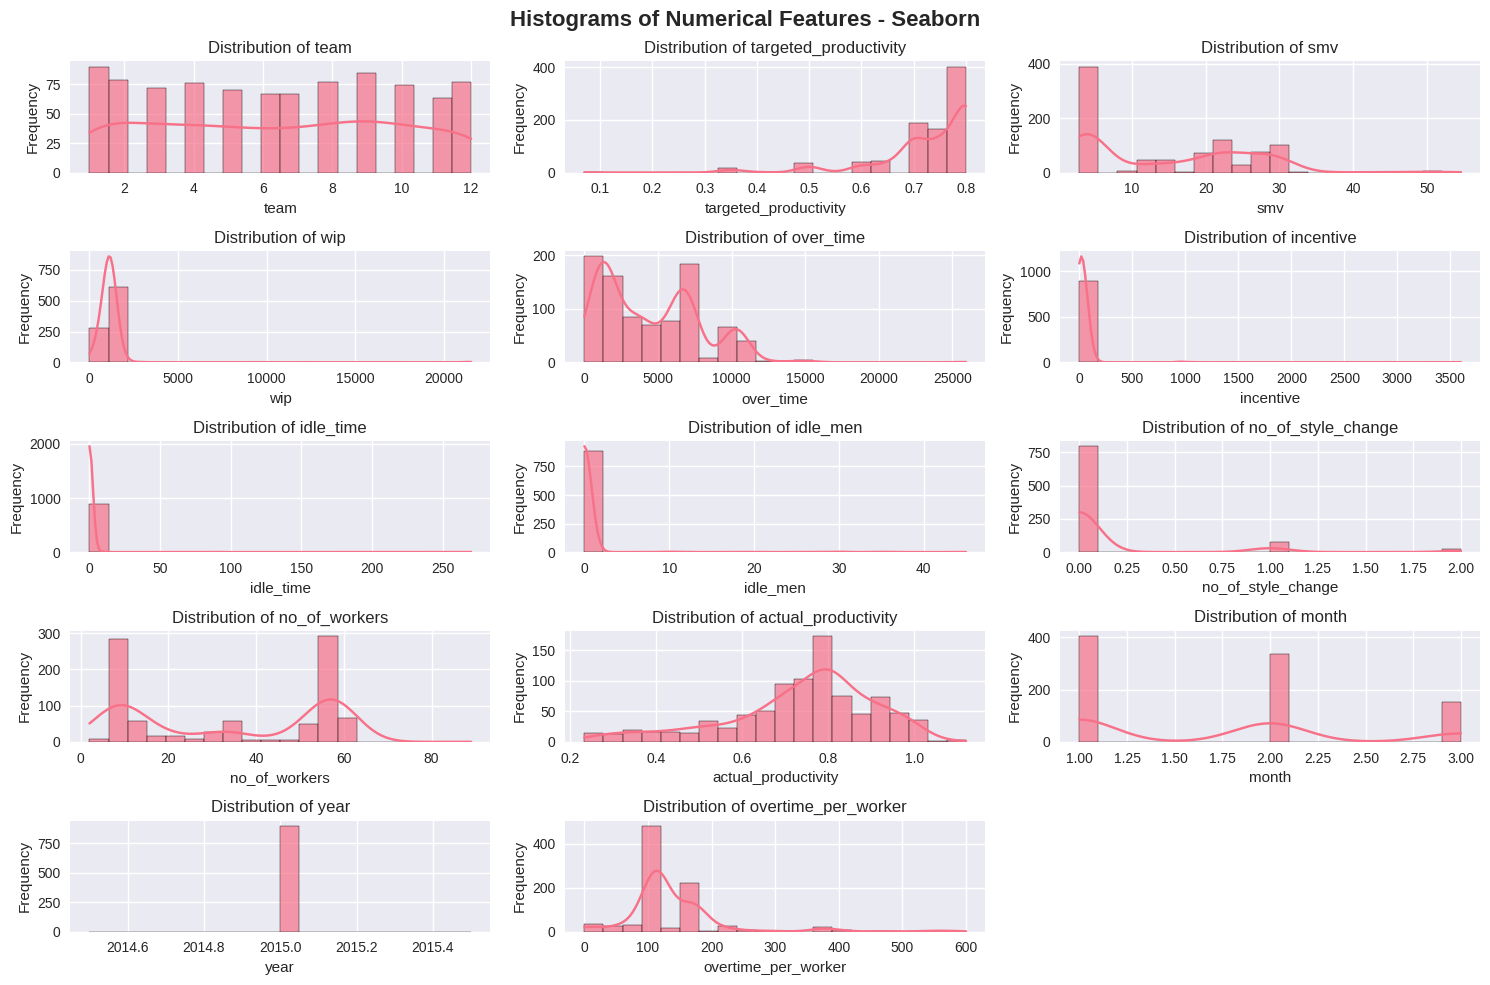

In [23]:
num_cols = df.select_dtypes(include=np.number).columns

# Calculate grid dimensions
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()  # Flatten in case of 2D array

for i, col in enumerate(num_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, bins=20, ax=axes[i], kde=True, alpha=0.7)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histograms of Numerical Features - Seaborn", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

productivity_level
Low       66.004963
Medium    21.836228
High      12.158809
Name: proportion, dtype: float64


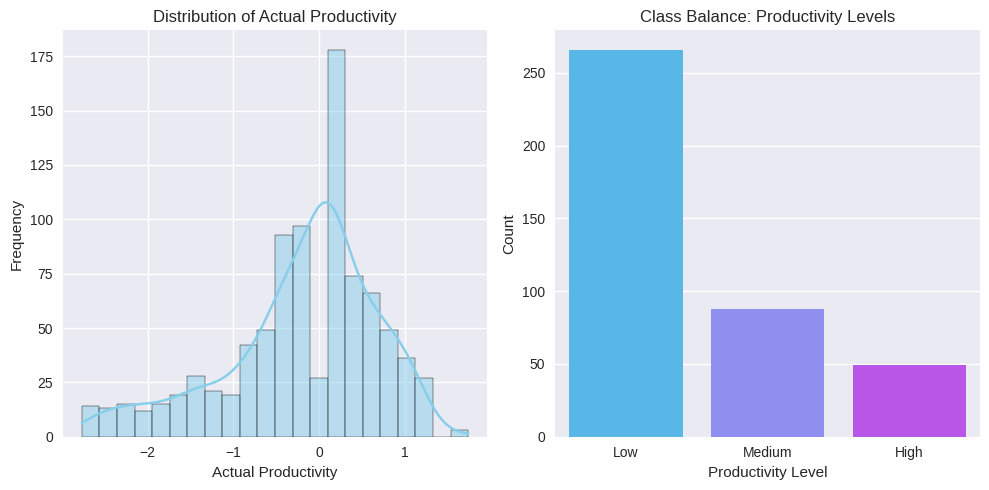

In [24]:
fig , ax = plt.subplots(1,2,figsize=(10,5))
# Distribution of Actual Productivity
ax1 = ax[0]
sns.histplot(df_encoded['actual_productivity'], kde=True,ax=ax1,color='skyblue')
ax1.set_title('Distribution of Actual Productivity')
ax1.set_xlabel('Actual Productivity')
ax1.set_ylabel('Frequency')

ax2 = ax[1]
df_encoded['productivity_level'] = pd.cut(
    df_encoded['actual_productivity'],
    bins=[0, 0.5, 0.8, 1],
    labels=['Low', 'Medium', 'High']
)

# Class Balance: Productivity Levels
print(df_encoded['productivity_level'].value_counts(normalize=True) * 100)
sns.countplot(x='productivity_level', data=df_encoded, palette='cool',ax=ax2)
ax2.set_title("Class Balance: Productivity Levels")
ax2.set_xlabel("Productivity Level")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [25]:
df_encoded.select_dtypes(include=np.number).describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,efficiency_gap,productivity_ratio,wip_per_worker,incentive_per_worker,idle_ratio,idle_men_ratio,incentive_efficiency
count,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,897.000000,8.970000e+02,897.000000,897.000000,897.000000,897.000000,897.000000
mean,0.064103,-0.185396,-0.016108,0.151948,0.100243,0.790948,0.455407,0.356745,0.138239,0.002648,-0.206208,0.020812,-9.637107e+03,0.085423,0.919534,0.291608,0.250509,-0.207149
std,0.585940,0.947364,0.573417,8.260928,0.616855,3.546885,9.513249,3.338400,0.413039,0.464059,0.879123,1.012173,3.006197e+05,5.800981,6.420247,4.921227,2.359493,0.802907
min,-0.833333,-6.800000,-0.641579,-6.763031,-0.725275,0.000000,0.000000,0.000000,0.000000,-0.666667,-2.766183,-5.502665,-2.572279e+06,-6.640473,0.000000,-0.000000,0.000000,-2.766183
25%,-0.500000,-0.500000,-0.586842,-1.000000,-0.461538,0.000000,0.000000,0.000000,0.000000,-0.520833,-0.633097,-0.373588,-2.924805e-01,-0.820566,0.000000,0.000000,0.000000,-0.499377
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.105409,4.935869e-01,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.500000,0.413158,0.000000,0.538462,1.000000,0.000000,0.000000,0.000000,0.479167,0.366903,0.388114,1.238715e+00,0.000000,0.690647,0.000000,0.000000,0.215372
max,1.000000,0.500000,2.077368,118.081389,4.021978,72.000000,270.000000,45.000000,2.000000,1.145833,1.738478,3.202456,1.127817e+06,80.970096,119.172414,132.868646,30.000000,1.738478


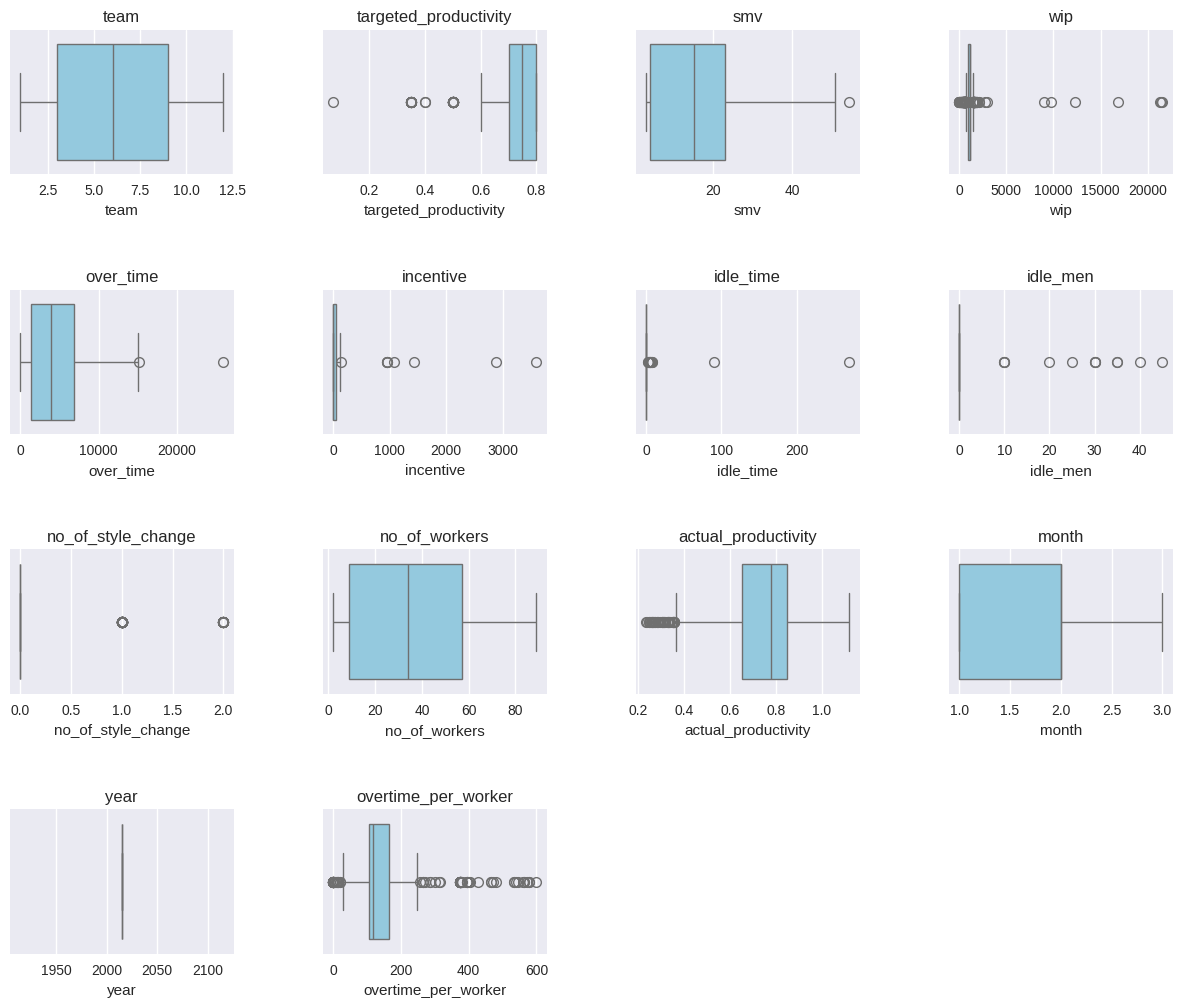

In [26]:
plt.figure(figsize=(15, 12)) # Increased figure height to accommodate more rows
num_cols = df.select_dtypes(include=np.number).columns
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4 # Calculate number of rows needed

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, 4, i) # Adjusted subplot grid
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(col)

# Add spacing between subplots
plt.subplots_adjust(hspace=0.8, wspace=0.4) # Adjusted spacing

plt.show()

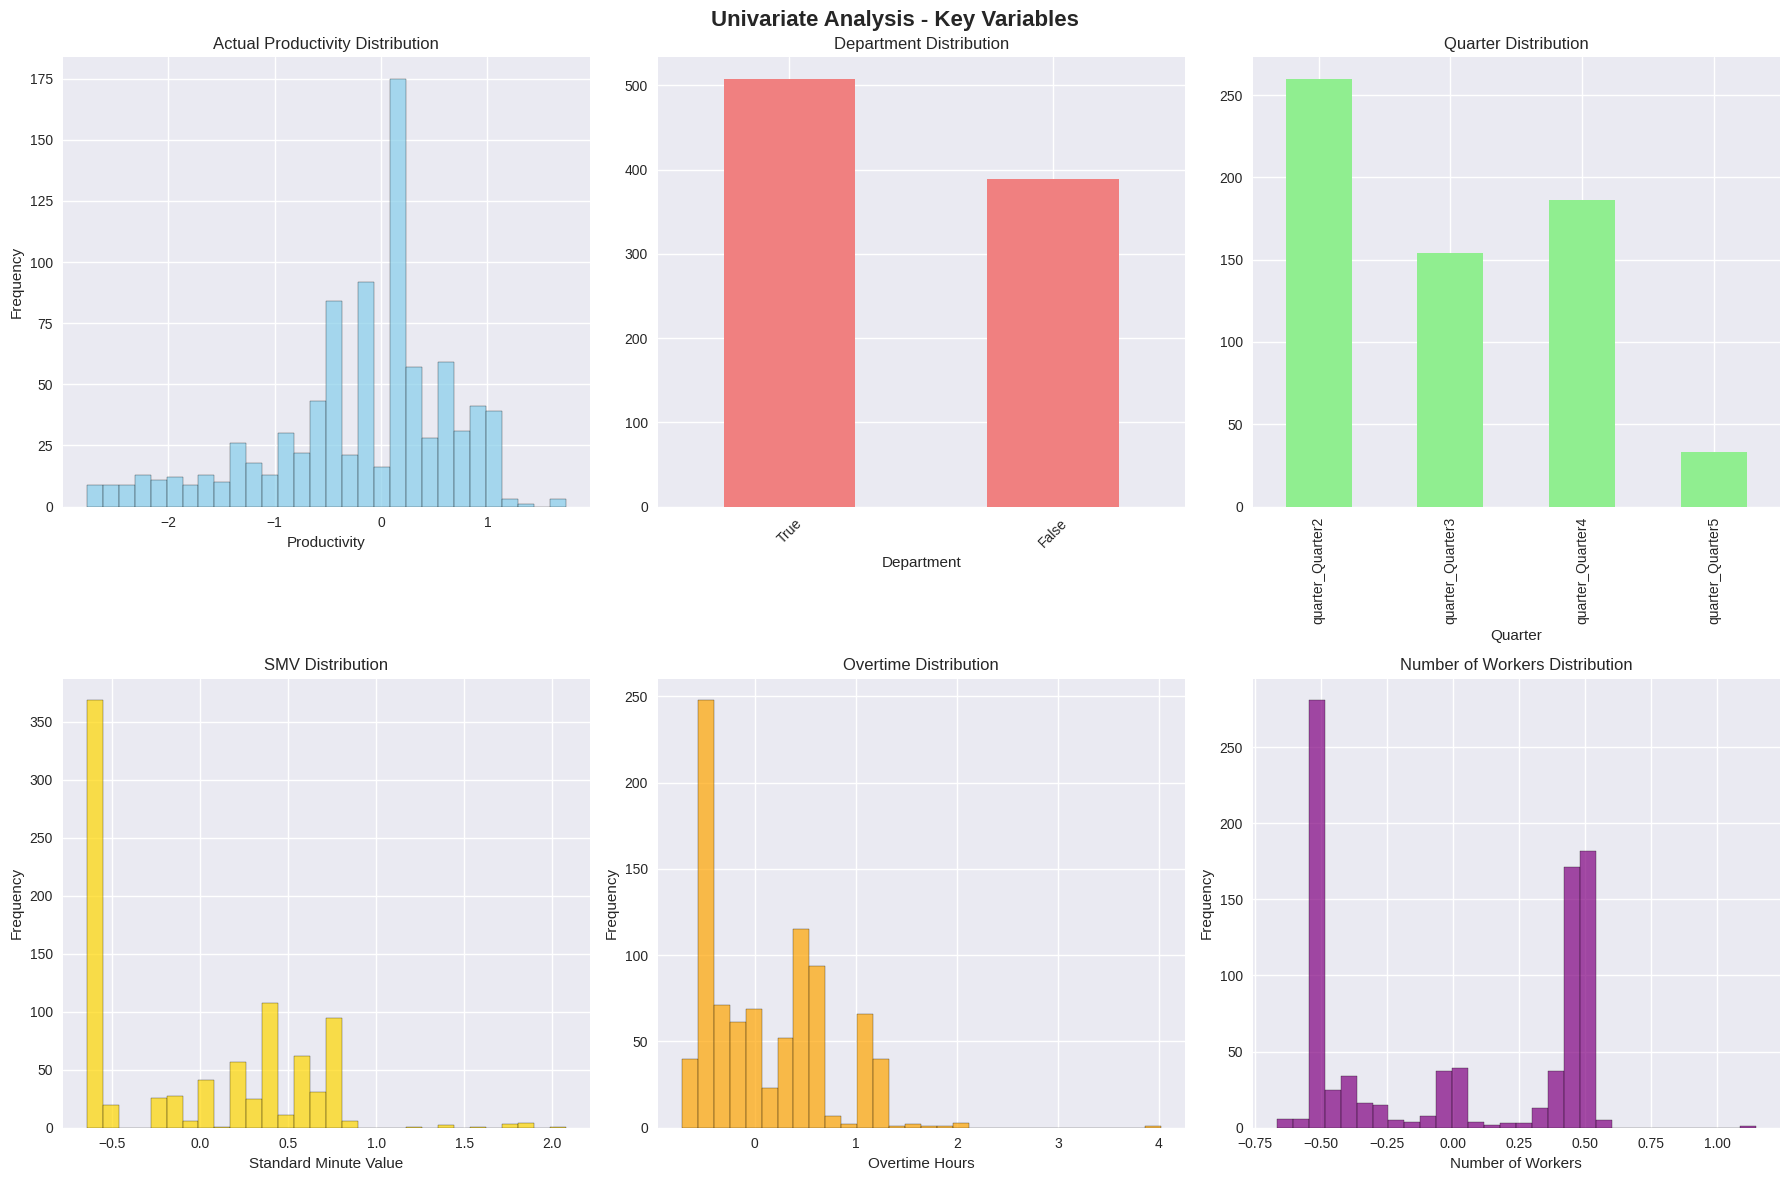

In [27]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Univariate Analysis - Key Variables', fontsize=16, fontweight='bold')

# Target variable distribution
axes[0,0].hist(df_encoded['actual_productivity'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Actual Productivity Distribution')
axes[0,0].set_xlabel('Productivity')
axes[0,0].set_ylabel('Frequency')

# Department distribution
df_encoded['department_sewing'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Department Distribution')
axes[0,1].set_xlabel('Department')
axes[0,1].tick_params(axis='x', rotation=45)

# Quarter distribution
df_encoded[['quarter_Quarter2', 'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5']].sum().plot(kind='bar', ax=axes[0,2], color='lightgreen')
axes[0,2].set_title('Quarter Distribution')
axes[0,2].set_xlabel('Quarter')

# SMV distribution
axes[1,0].hist(df_encoded['smv'].dropna(), bins=30, alpha=0.7, color='gold', edgecolor='black')
axes[1,0].set_title('SMV Distribution')
axes[1,0].set_xlabel('Standard Minute Value')
axes[1,0].set_ylabel('Frequency')

# Overtime distribution
axes[1,1].hist(df_encoded['over_time'].dropna(), bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1,1].set_title('Overtime Distribution')
axes[1,1].set_xlabel('Overtime Hours')
axes[1,1].set_ylabel('Frequency')

# Number of workers distribution
axes[1,2].hist(df_encoded['no_of_workers'].dropna(), bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1,2].set_title('Number of Workers Distribution')
axes[1,2].set_xlabel('Number of Workers')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Univariate Analysis - Insights

Based on the univariate visualizations:

*   **Actual Productivity Distribution**: This histogram shows the distribution of the target variable, actual productivity. It helps understand the typical range of productivity values and if the distribution is skewed or has multiple peaks.

*   **Department Distribution**: This bar plot shows the count of observations for each department (Sewing and Finishing). It indicates the proportion of data points belonging to each department.

*   **Quarter Distribution**: This bar plot shows the count of observations for each quarter (Quarter 2, 3, 4, and 5). It helps understand how the data is distributed across different quarters.

*   **SMV Distribution**: This histogram shows the distribution of Standard Minute Value (SMV). It indicates the typical standard time allocated for tasks and the variability in SMV.

*   **Overtime Distribution**: This histogram shows the distribution of overtime hours. It helps understand the frequency and amount of overtime worked.

*   **Number of Workers Distribution**: This histogram shows the distribution of the number of workers in a team. It indicates the typical team sizes and their frequency in the dataset.

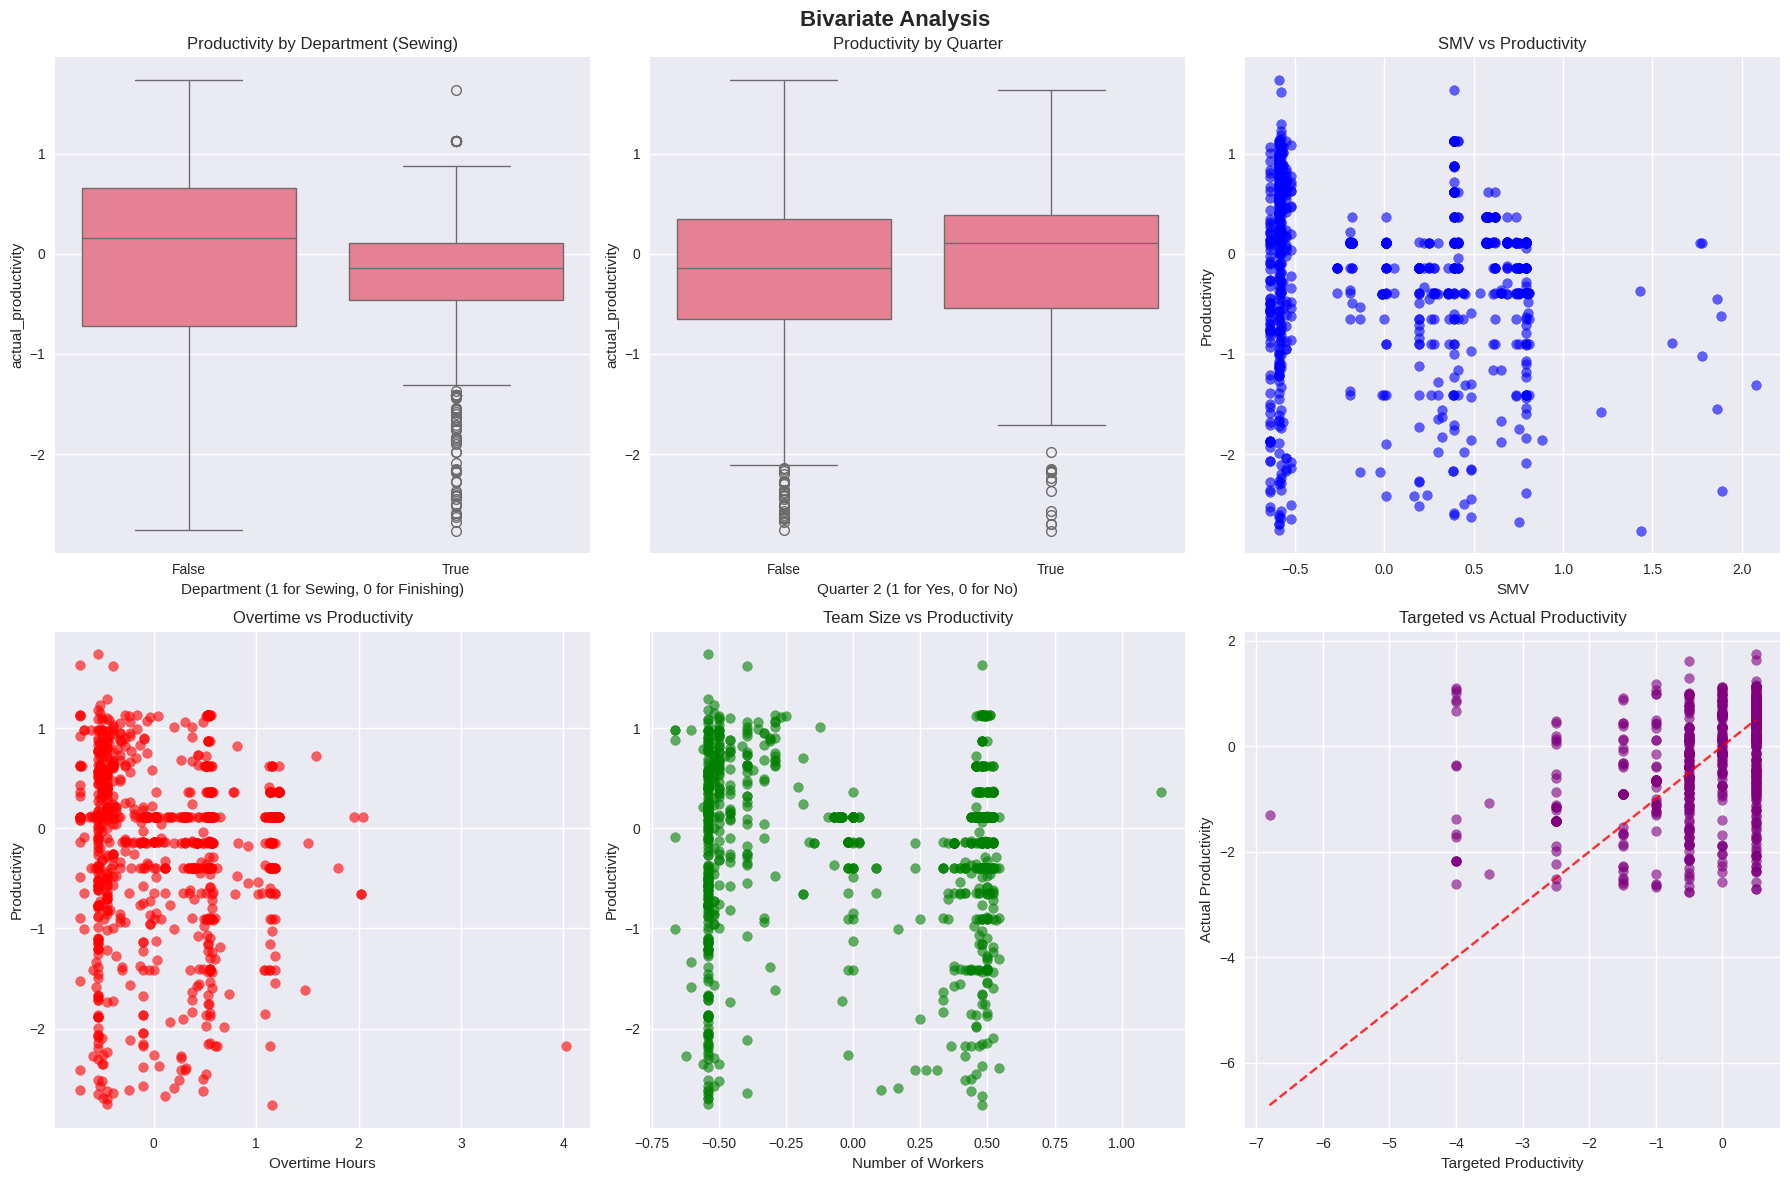

In [28]:
# Create bivariate visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

# Productivity by Department
sns.boxplot(data=df_encoded, x='department_sewing', y='actual_productivity', ax=axes[0,0])
axes[0,0].set_title('Productivity by Department (Sewing)')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].set_xlabel('Department (1 for Sewing, 0 for Finishing)')


# Productivity by Quarter
sns.boxplot(data=df_encoded, x='quarter_Quarter2', y='actual_productivity', ax=axes[0,1])
axes[0,1].set_title('Productivity by Quarter')
axes[0,1].set_xlabel('Quarter 2 (1 for Yes, 0 for No)')


# SMV vs Productivity
axes[0,2].scatter(df_encoded['smv'], df_encoded['actual_productivity'], alpha=0.6, color='blue')
axes[0,2].set_title('SMV vs Productivity')
axes[0,2].set_xlabel('SMV')
axes[0,2].set_ylabel('Productivity')

# Overtime vs Productivity
axes[1,0].scatter(df_encoded['over_time'], df_encoded['actual_productivity'], alpha=0.6, color='red')
axes[1,0].set_title('Overtime vs Productivity')
axes[1,0].set_xlabel('Overtime Hours')
axes[1,0].set_ylabel('Productivity')

# Number of Workers vs Productivity
axes[1,1].scatter(df_encoded['no_of_workers'], df_encoded['actual_productivity'], alpha=0.6, color='green')
axes[1,1].set_title('Team Size vs Productivity')
axes[1,1].set_xlabel('Number of Workers')
axes[1,1].set_ylabel('Productivity')

# Targeted vs Actual Productivity
axes[1,2].scatter(df_encoded['targeted_productivity'], df_encoded['actual_productivity'], alpha=0.6, color='purple')
axes[1,2].set_title('Targeted vs Actual Productivity')
axes[1,2].set_xlabel('Targeted Productivity')
axes[1,2].set_ylabel('Actual Productivity')
axes[1,2].plot([df_encoded['targeted_productivity'].min(), df_encoded['targeted_productivity'].max()],
               [df_encoded['targeted_productivity'].min(), df_encoded['targeted_productivity'].max()], 'r--', alpha=0.8)  # Reference line


plt.tight_layout()
plt.show()

## Bivariate Analysis - Insights

Based on the bivariate visualizations:

*   **Productivity by Department (Sewing vs. Finishing)**: The boxplot shows a comparison of actual productivity between the sewing and finishing departments. We can observe the median productivity for each department and the spread of the data. This helps understand if one department is generally more productive than the other.

*   **Productivity by Quarter**: This boxplot compares actual productivity across different quarters (specifically Quarter 2 vs. others, based on the dummy variable). We can see if there are significant differences in productivity levels across the quarters.

*   **SMV vs Productivity**: The scatter plot visualizes the relationship between Standard Minute Value (SMV) and actual productivity. This can help identify if there's a correlation between the standard time allocated for a task and the actual productivity achieved.

*   **Overtime vs Productivity**: This scatter plot shows the relationship between overtime hours and actual productivity. We can observe if working more overtime hours is associated with higher or lower productivity.

*   **Team Size vs Productivity**: The scatter plot illustrates the relationship between the number of workers in a team and their actual productivity. This can help understand if larger or smaller teams tend to be more productive.

*   **Targeted vs Actual Productivity**: This scatter plot compares the targeted productivity with the actual productivity. The red dashed line represents where targeted productivity equals actual productivity. Points above the line indicate actual productivity exceeding the target, while points below the line indicate actual productivity falling short of the target. This plot is useful for assessing how well teams are meeting their productivity goals.

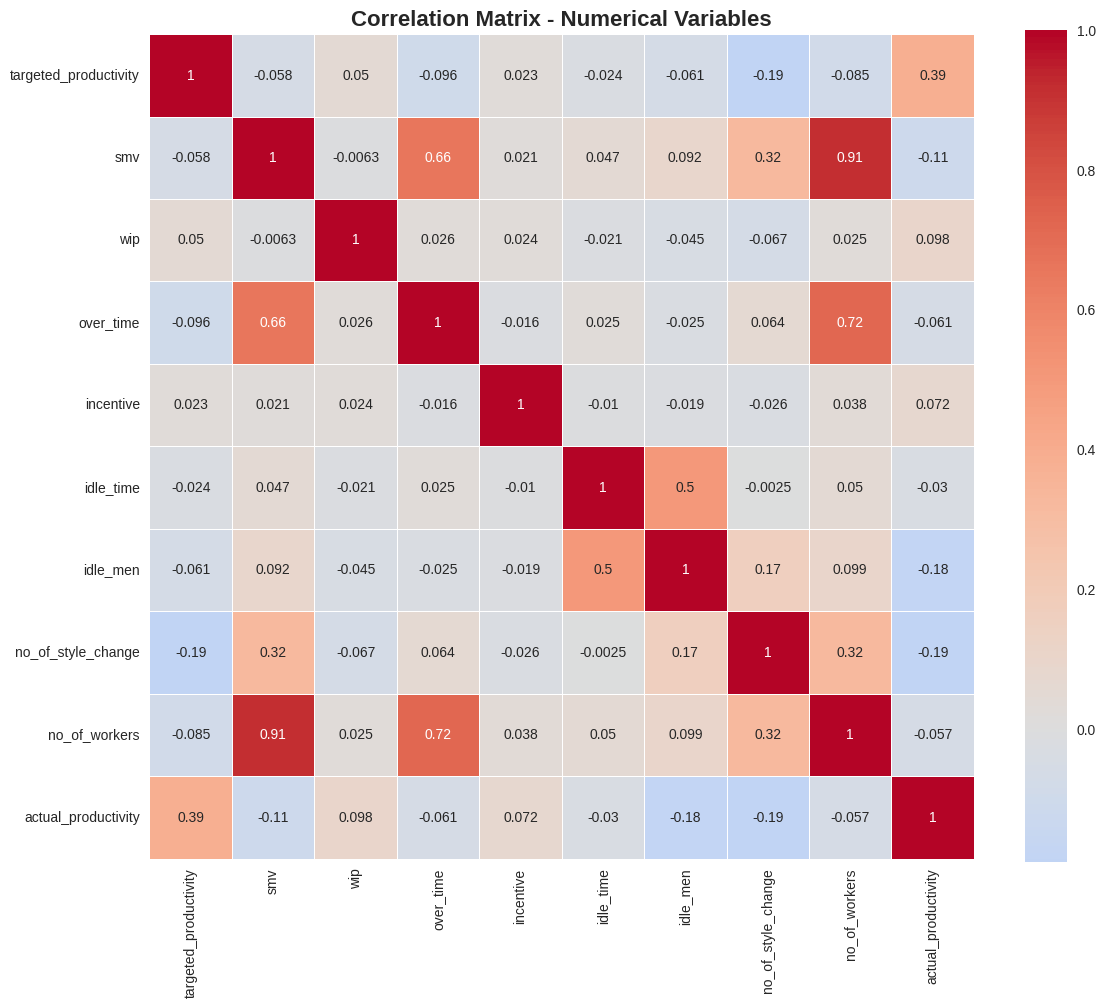

In [29]:
# CORRELATION ANALYSIS

numerical_cols = ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
                  'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

correlation_matrix = df_encoded[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Top correlations with actual productivity
print("\nTop correlations with Actual Productivity:")
prod_corr = correlation_matrix['actual_productivity'].sort_values(ascending=False)
print(prod_corr)


Top correlations with Actual Productivity:
actual_productivity      1.000000
targeted_productivity    0.387742
wip                      0.098213
incentive                0.072045
idle_time               -0.030345
no_of_workers           -0.057238
over_time               -0.060788
smv                     -0.112902
idle_men                -0.182896
no_of_style_change      -0.191145
Name: actual_productivity, dtype: float64


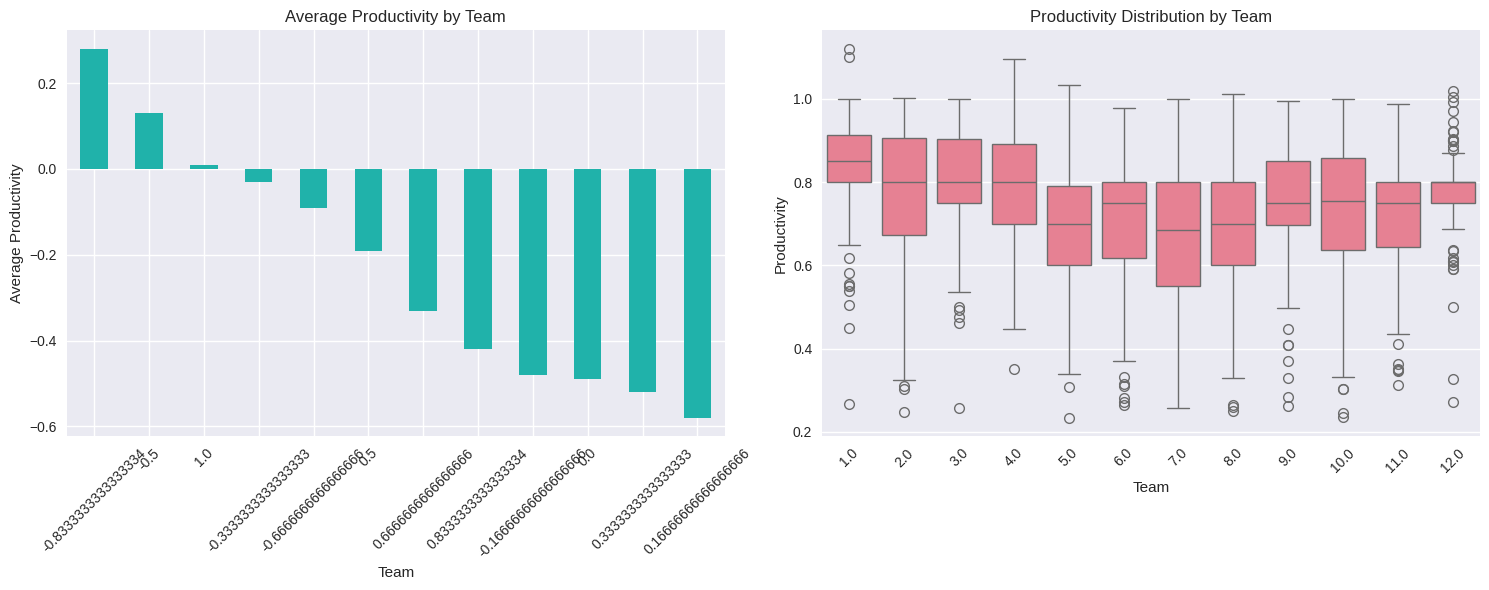

In [31]:
# Team performance
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
team_performance = df_encoded.groupby('team')['actual_productivity'].mean().sort_values(ascending=False).round(2)
team_performance.plot(kind='bar', color='lightseagreen')
plt.title('Average Productivity by Team')
plt.xlabel('Team')
plt.ylabel('Average Productivity')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='team', y='actual_productivity')
plt.title('Productivity Distribution by Team')
plt.xlabel('Team')
plt.ylabel('Productivity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

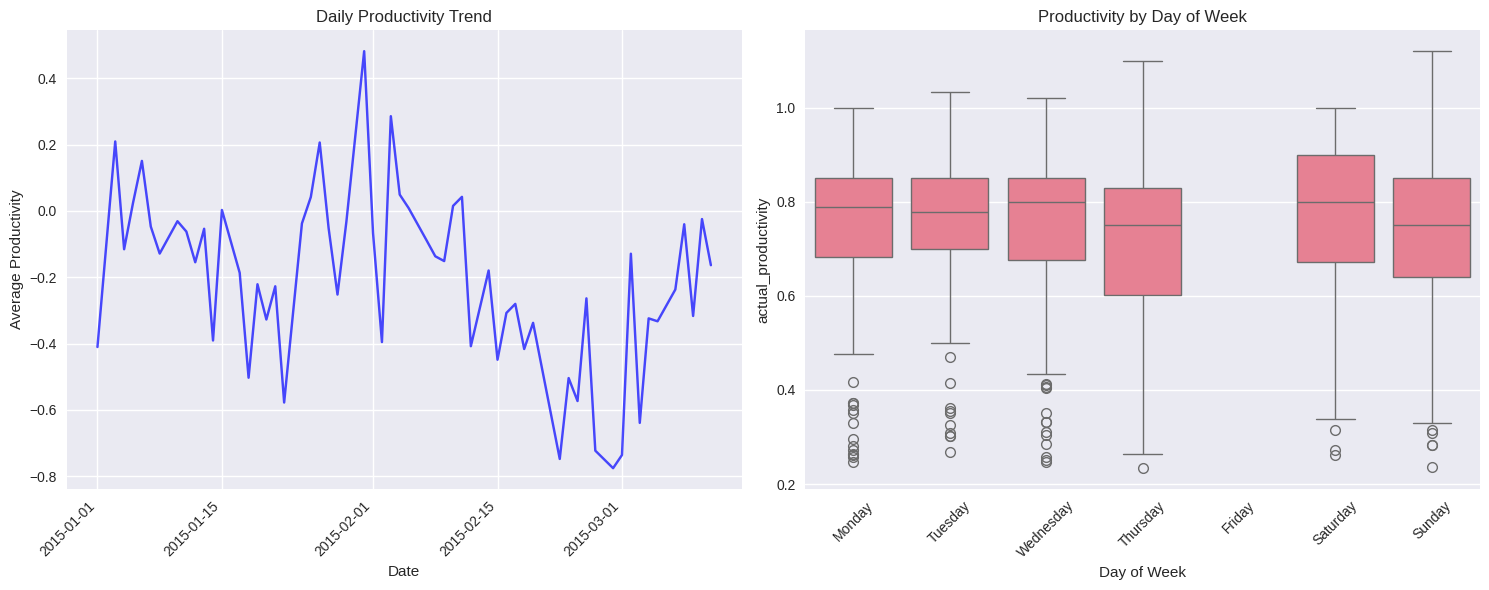

In [32]:
# Productivity trends over time
plt.figure(figsize=(15, 6))

# Daily productivity trend
plt.subplot(1, 2, 1)
daily_avg = df_encoded.groupby('date')['actual_productivity'].mean()
daily_avg.plot(alpha=0.7, color='blue')
plt.title('Daily Productivity Trend')
plt.xlabel('Date')
plt.ylabel('Average Productivity')
plt.xticks(rotation=45)

# Productivity by day of week
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df, x='day_of_week', y='actual_productivity', order=day_order)
plt.title('Productivity by Day of Week')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Model Training and Evaluation

In [44]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['actual_productivity', 'productivity_level'])
y = df_encoded['actual_productivity']                 # target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% test, 80% train
    random_state=42,
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 717 rows
Test set: 180 rows


In [34]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [35]:
# Build pipeline with PCA + Linear Regression (Base Model)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

In [36]:
param_grid = [
    {
        'regressor': [LinearRegression()],
        'regressor__fit_intercept': [True, False]
    },
    {
        'regressor': [Lasso()],
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]
    },
    {
        'regressor': [Ridge()],
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]
    },
    {
        'regressor': [SVR()],
        'regressor__kernel': ['linear', 'rbf'],
        'regressor__C': [0.1, 1, 10]
    },
    {
        'regressor': [RandomForestRegressor()],
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10]
    }
]

In [45]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Model:", grid.best_estimator_)
print("Best Parameters:", grid.best_params_)
print("Best R² Score:", grid.best_score_)

Best Model: Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('regressor', Ridge(alpha=10))])
Best Parameters: {'regressor': Ridge(), 'regressor__alpha': 10}
Best R² Score: 0.9651839116601926


In [48]:
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error

y_pred = grid.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Test R²: 0.9715504559775374
Test RMSE: 0.13937236240342882
Test MAE: 0.0849920552323759
